In [3]:
%load_ext autoreload
%autoreload 2

from analysis import *
from demographic_analysis import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load and preprocess data

In [4]:
pub_folder = "../survey_data"
clean_data    = pd.read_csv(f"{pub_folder}/likert-responses.csv").rename(columns={"respondent_id": "prolific_id"})
ft_data       = pd.read_csv(f"{pub_folder}/free_text_responses.csv").rename(columns={"respondent_id": "prolific_id"})
prolific      = pd.read_csv(f"{pub_folder}/participant_demographics.csv").rename(columns={"respondent_id": "prolific_id"})
likert_num2question = pd.read_csv(f"{pub_folder}/likert_questions.csv").set_index("likert")["question"].to_dict()

# Participant Demographics

In [5]:
for c in prolific.columns:
    print(c) 

prolific_id
Age
Sex
Ethnicity simplified
Political spectrum (us)
Student status
Employment status


In [6]:
# Columns to summarize
numeric_cols = [
    "Age",
]

categorical_cols = [
    "Political spectrum (us)",
    "Sex",
    "Ethnicity simplified",
    "Student status",
    "Employment status",
]

political_spectrum_palette = {"Conservative": "firebrick", "Moderate": "#777777", "Liberal": "steelblue"}

In [7]:
import os
DEMO_FIG_DIR = "../figures/demographics"
os.makedirs(DEMO_FIG_DIR, exist_ok=True)

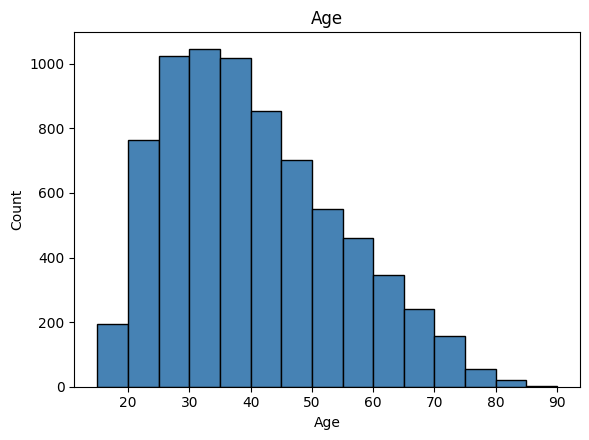

count    7434.000000
mean       40.089857
std        13.980036
min        18.000000
25%        29.000000
50%        38.000000
75%        49.000000
max        86.000000
Name: Age, dtype: float64


In [8]:
age_numeric = pd.to_numeric(prolific["Age"], errors="coerce").dropna()
plot_age_histogram(df=prolific, bins=np.arange(15, 95, 5), save_path=f"{DEMO_FIG_DIR}/age.pdf")

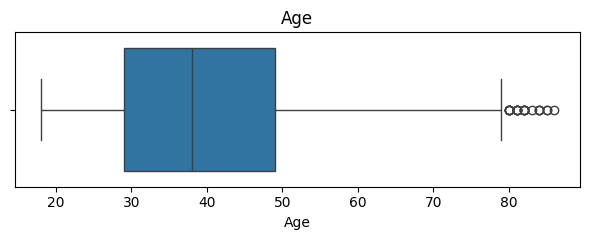

count    7434.000000
mean       40.089857
std        13.980036
min        18.000000
25%        29.000000
50%        38.000000
75%        49.000000
max        86.000000
Name: Age, dtype: float64


In [9]:
plot_numeric_boxplot(prolific, col_name="Age")

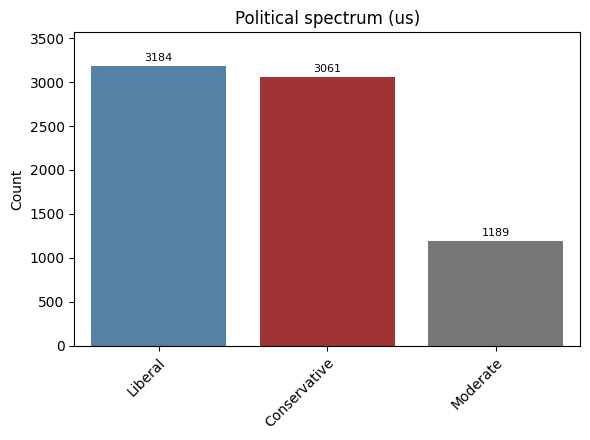

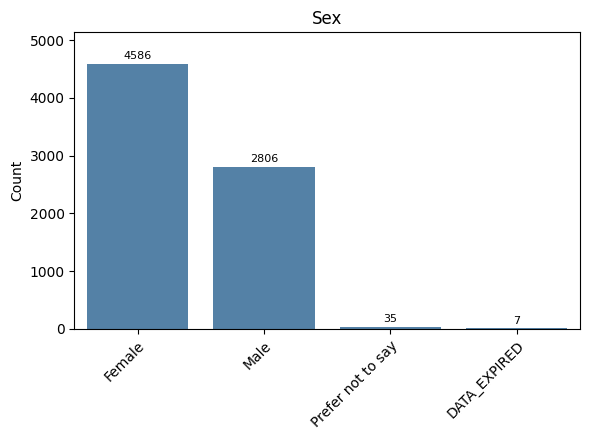

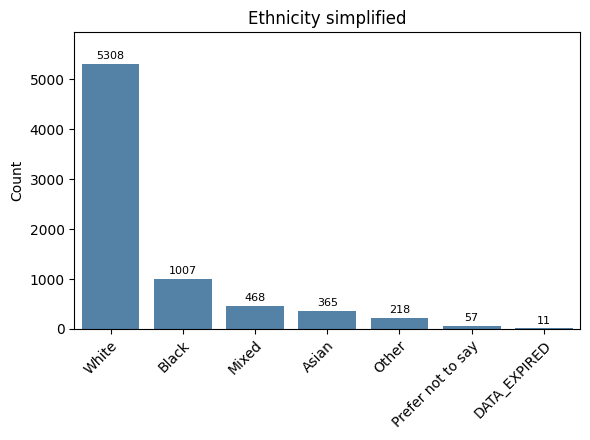

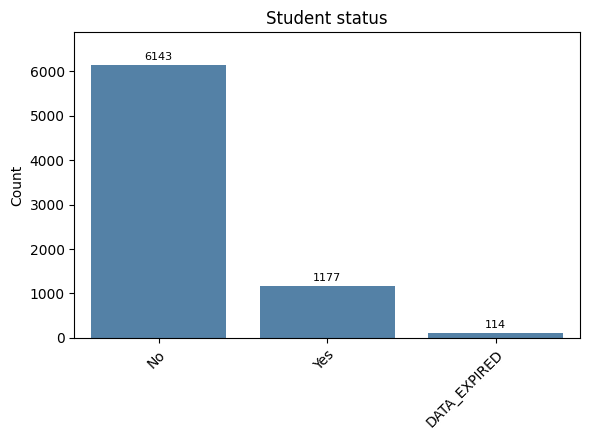

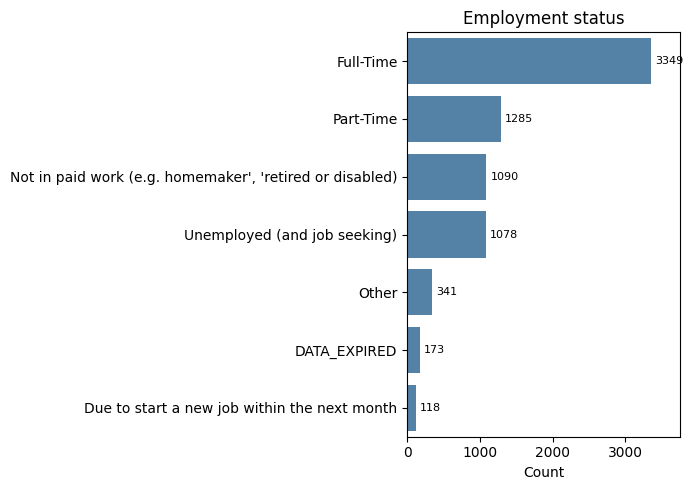

In [10]:
col_to_filename = {
    "Political spectrum (us)": "political-spectrum.pdf",
    "Sex": "sex.pdf",
    "Ethnicity simplified": "ethnicity.pdf",
    "Student status": "student.pdf",
    "Employment status": "employment.pdf",
}

for col in categorical_cols:
    palette = political_spectrum_palette if col == "Political spectrum (us)" else None
    save_path = f"{DEMO_FIG_DIR}/{col_to_filename[col]}"
    plot_categorical_counts(df=prolific, col_name=col, max_categories=200, palette=palette, save_path=save_path)

## Contingency Table: Sex x Political Spectrum

Counts (Sex x Political spectrum (us)):


Political spectrum (us),Conservative,Liberal,Moderate
Sex,,,
DATA_EXPIRED,2,3,2
Female,1764,2149,673
Male,1290,1009,507
Prefer not to say,5,23,7



Row % (within each Sex):


Political spectrum (us),Conservative,Liberal,Moderate
Sex,,,
DATA_EXPIRED,28.6,42.9,28.6
Female,38.5,46.9,14.7
Male,46.0,36.0,18.1
Prefer not to say,14.3,65.7,20.0



Column % (within each Political spectrum (us) category):


Political spectrum (us),Conservative,Liberal,Moderate
Sex,,,
DATA_EXPIRED,0.1,0.1,0.2
Female,57.6,67.5,56.6
Male,42.1,31.7,42.6
Prefer not to say,0.2,0.7,0.6


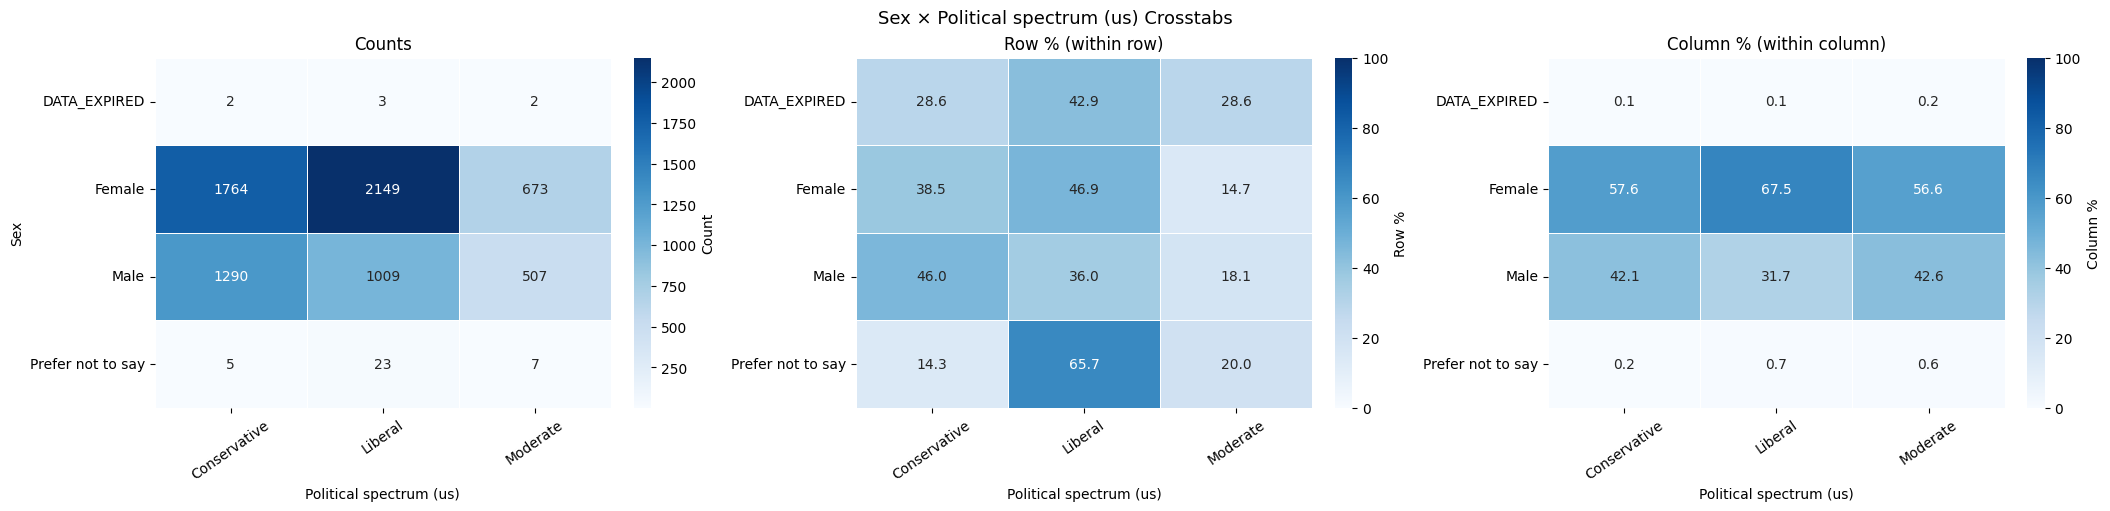

In [11]:
sex_political_spectrum_tables = make_crosstab_tables(
    prolific,
    row_col="Sex",
    col_col="Political spectrum (us)",
    include_missing=True,
)

# can modify layout="combined" or layout="separate"
plot_crosstab_heatmaps(sex_political_spectrum_tables, row_col="Sex", col_col="Political spectrum (us)", layout="combined")

## Contingency Table: Ethnicity x Political Spectrum

Counts (Ethnicity simplified x Political spectrum (us)):


Political spectrum (us),Conservative,Liberal,Moderate
Ethnicity simplified,,,
Asian,87,207,71
Black,384,456,167
DATA_EXPIRED,10,1,0
Mixed,142,247,79
Other,81,100,37
Prefer not to say,19,29,9
White,2338,2144,826



Row % (within each Ethnicity simplified):


Political spectrum (us),Conservative,Liberal,Moderate
Ethnicity simplified,,,
Asian,23.8,56.7,19.5
Black,38.1,45.3,16.6
DATA_EXPIRED,90.9,9.1,0.0
Mixed,30.3,52.8,16.9
Other,37.2,45.9,17.0
Prefer not to say,33.3,50.9,15.8
White,44.0,40.4,15.6



Column % (within each Political spectrum (us) category):


Political spectrum (us),Conservative,Liberal,Moderate
Ethnicity simplified,,,
Asian,2.8,6.5,6.0
Black,12.5,14.3,14.0
DATA_EXPIRED,0.3,0.0,0.0
Mixed,4.6,7.8,6.6
Other,2.6,3.1,3.1
Prefer not to say,0.6,0.9,0.8
White,76.4,67.3,69.5


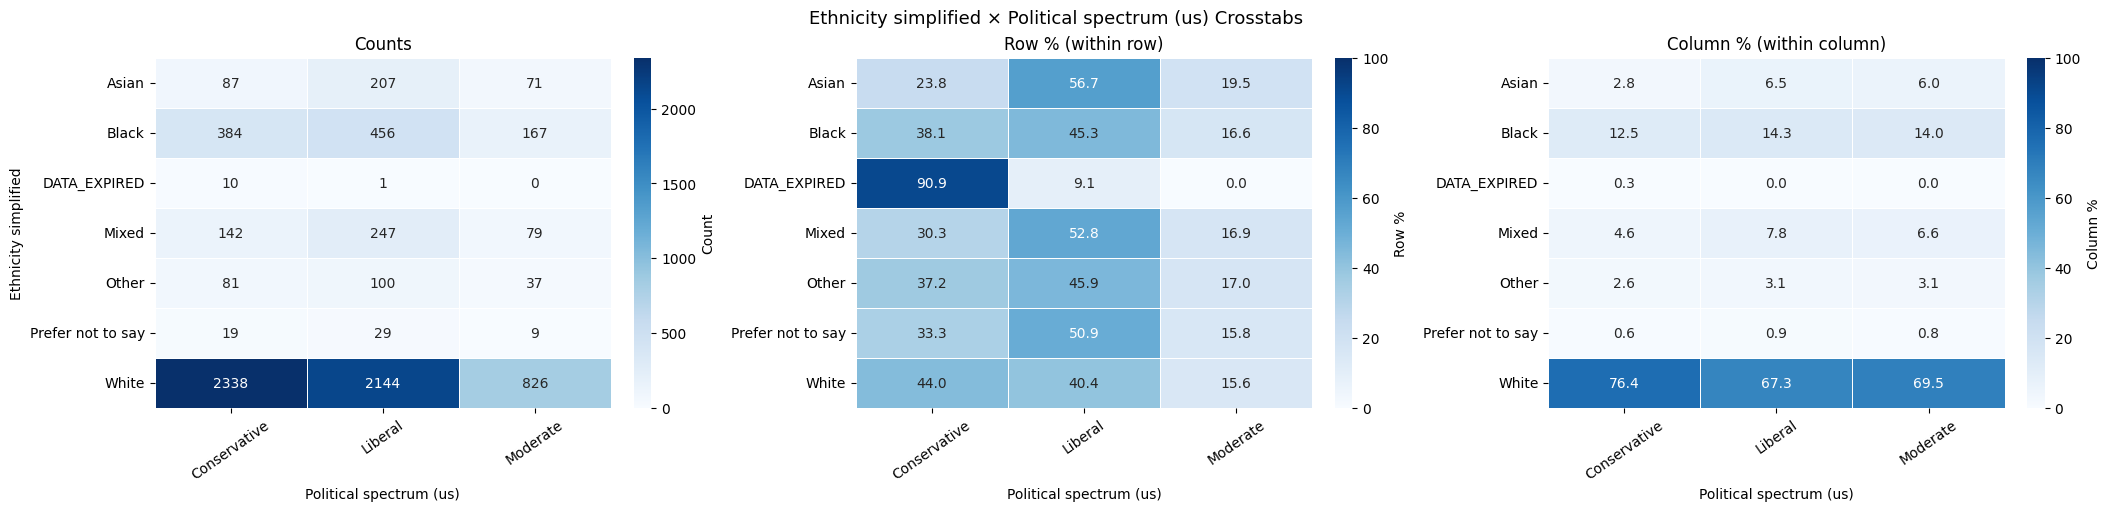

In [12]:
ethnicity_political_spectrum_tables = make_crosstab_tables(
    prolific,
    row_col="Ethnicity simplified",
    col_col="Political spectrum (us)",
    include_missing=True
)

# can modify layout="combined" or layout="separate"
plot_crosstab_heatmaps(ethnicity_political_spectrum_tables, row_col="Ethnicity simplified", col_col="Political spectrum (us)", layout="combined")

## Contingency Table: Student Status x Political Spectrum

Counts (Student status x Political spectrum (us)):


Political spectrum (us),Conservative,Liberal,Moderate
Student status,,,
DATA_EXPIRED,59,44,11
No,2552,2576,1015
Yes,450,564,163



Row % (within each Student status):


Political spectrum (us),Conservative,Liberal,Moderate
Student status,,,
DATA_EXPIRED,51.8,38.6,9.6
No,41.5,41.9,16.5
Yes,38.2,47.9,13.8



Column % (within each Political spectrum (us) category):


Political spectrum (us),Conservative,Liberal,Moderate
Student status,,,
DATA_EXPIRED,1.9,1.4,0.9
No,83.4,80.9,85.4
Yes,14.7,17.7,13.7


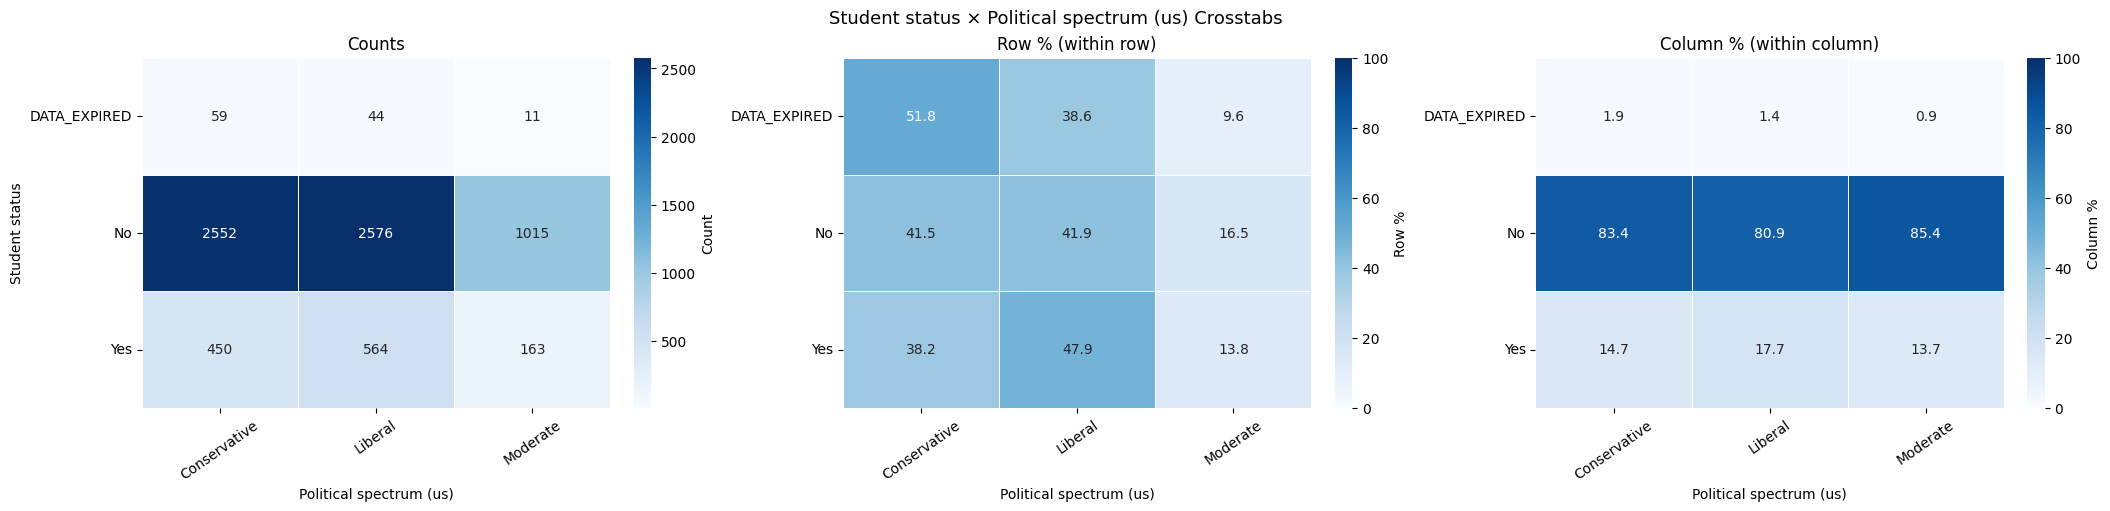

In [13]:
student_political_spectrum_tables = make_crosstab_tables(
    prolific,
    row_col="Student status",
    col_col="Political spectrum (us)",
    include_missing=True
)

# can modify layout="combined" or layout="separate"
plot_crosstab_heatmaps(student_political_spectrum_tables, row_col="Student status", col_col="Political spectrum (us)", layout="combined")

## Contingency Table: Employment Status x Political Spectrum

Counts (Employment status x Political spectrum (us)):


Political spectrum (us),Conservative,Liberal,Moderate
Employment status,,,
DATA_EXPIRED,80,71,22
Due to start a new job within the next month,37,53,28
Full-Time,1407,1392,550
"Not in paid work (e.g. homemaker', 'retired or disabled)",503,424,163
Other,126,145,70
Part-Time,540,564,181
Unemployed (and job seeking),368,535,175



Row % (within each Employment status):


Political spectrum (us),Conservative,Liberal,Moderate
Employment status,,,
DATA_EXPIRED,46.2,41.0,12.7
Due to start a new job within the next month,31.4,44.9,23.7
Full-Time,42.0,41.6,16.4
"Not in paid work (e.g. homemaker', 'retired or disabled)",46.1,38.9,15.0
Other,37.0,42.5,20.5
Part-Time,42.0,43.9,14.1
Unemployed (and job seeking),34.1,49.6,16.2



Column % (within each Political spectrum (us) category):


Political spectrum (us),Conservative,Liberal,Moderate
Employment status,,,
DATA_EXPIRED,2.6,2.2,1.9
Due to start a new job within the next month,1.2,1.7,2.4
Full-Time,46.0,43.7,46.3
"Not in paid work (e.g. homemaker', 'retired or disabled)",16.4,13.3,13.7
Other,4.1,4.6,5.9
Part-Time,17.6,17.7,15.2
Unemployed (and job seeking),12.0,16.8,14.7


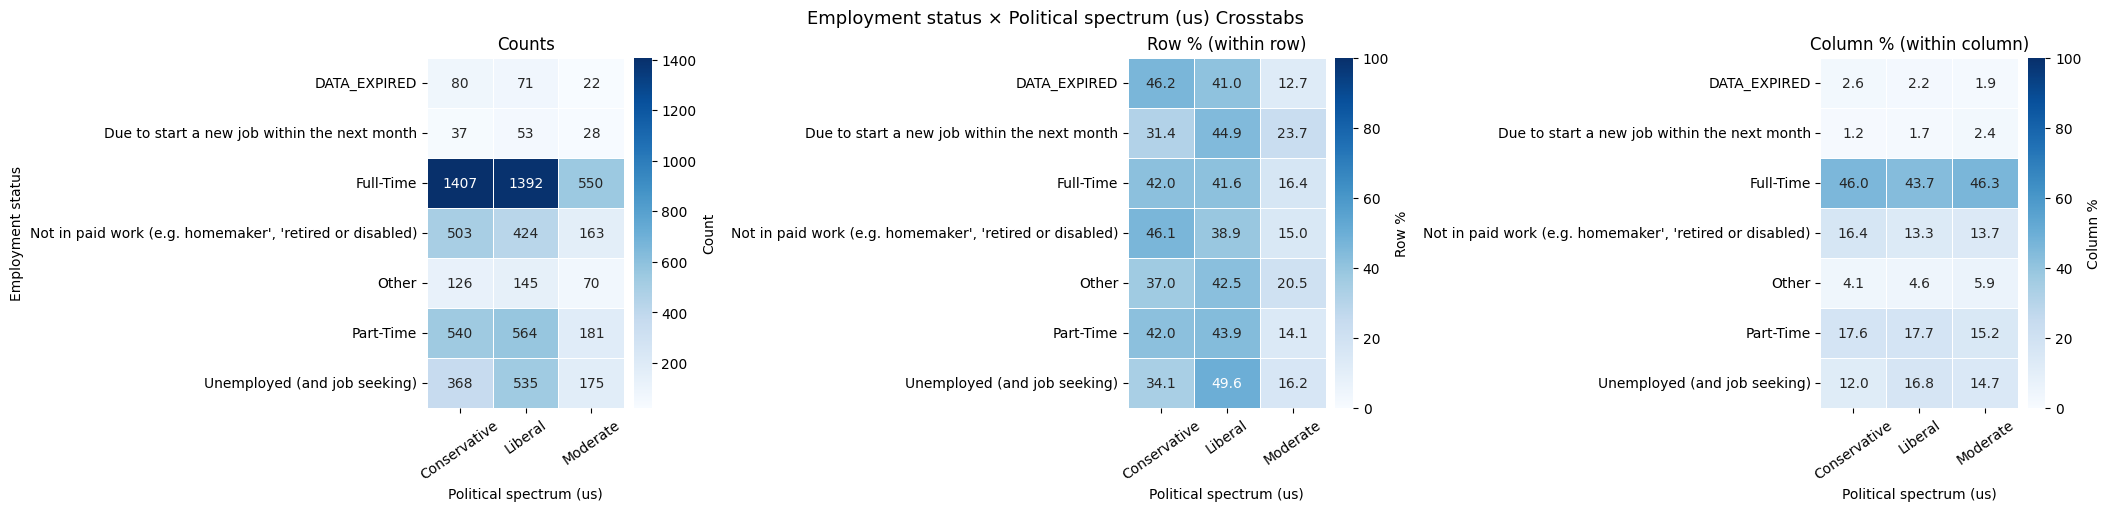

In [14]:
employment_political_spectrum_tables = make_crosstab_tables(
    prolific,
    row_col="Employment status",
    col_col="Political spectrum (us)",
    include_missing=True
)

# can modify layout="combined" or layout="separate"
plot_crosstab_heatmaps(employment_political_spectrum_tables, row_col="Employment status", col_col="Political spectrum (us)", layout="combined")

## Age x Political spectrum (us)

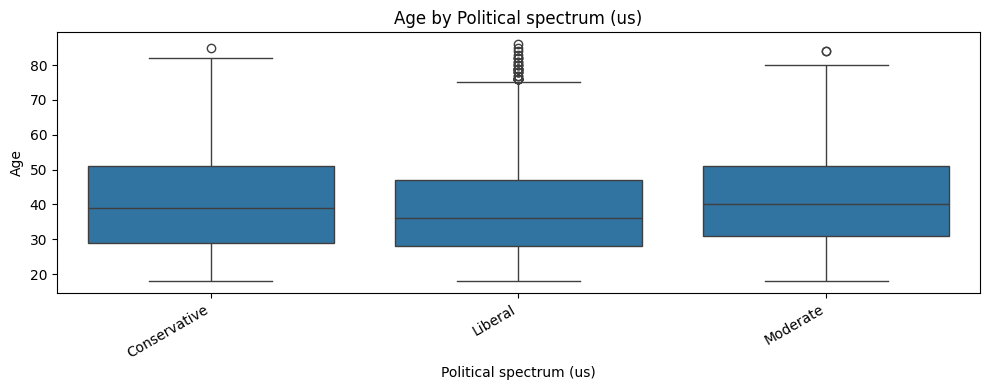

Age summary by Political spectrum (us):


,count,mean,std,min,25%,50%,75%,max
Political spectrum (us),,,,,,,,
Conservative,3061.0,40.94,14.24,18.0,29.0,39.0,51.0,85.0
Liberal,3184.0,38.69,13.73,18.0,28.0,36.0,47.0,86.0
Moderate,1189.0,41.66,13.65,18.0,31.0,40.0,51.0,84.0


In [15]:
joint = prolific.copy()
joint["Age_num"] = pd.to_numeric(joint["Age"], errors="coerce")

plot_df = joint.dropna(subset=["Age_num", "Political spectrum (us)"])
plt.figure(figsize=(10, 4))
sns.boxplot(data=plot_df, x="Political spectrum (us)", y="Age_num")
plt.title("Age by Political spectrum (us)")
plt.xlabel("Political spectrum (us)")
plt.ylabel("Age")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Age summary by Political spectrum (us):")
display(plot_df.groupby("Political spectrum (us)")["Age_num"].describe().round(2))

### Violin plot: Age x Political spectrum (us)

/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site

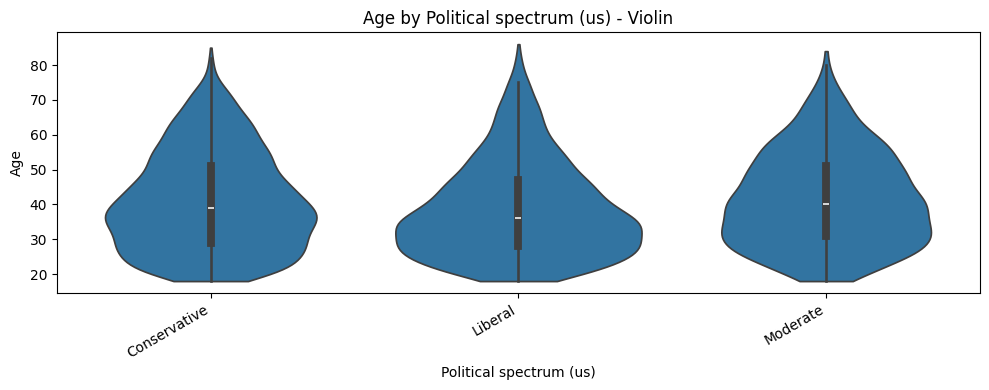

In [16]:
joint = prolific.copy()
joint["Age_num"] = pd.to_numeric(joint["Age"], errors="coerce")

plot_df = joint.dropna(subset=["Age_num", "Political spectrum (us)"])
plt.figure(figsize=(10, 4))
sns.violinplot(data=plot_df, x="Political spectrum (us)", y="Age_num", inner="box", cut=0)
plt.title("Age by Political spectrum (us) - Violin")
plt.xlabel("Political spectrum (us)")
plt.ylabel("Age")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Age x Employment status

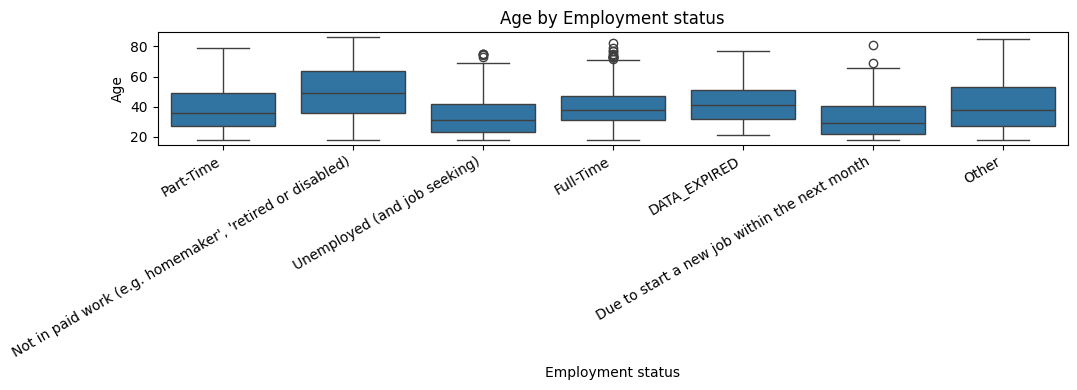

Age summary by Employment status:


,count,mean,std,min,25%,50%,75%,max
Employment status,,,,,,,,
DATA_EXPIRED,173.0,42.39,13.77,21.0,32.0,41.0,51.00,77.0
Due to start a new job within the next month,118.0,33.16,13.55,18.0,22.0,29.0,40.75,81.0
Full-Time,3349.0,39.66,11.29,18.0,31.0,38.0,47.00,82.0
"Not in paid work (e.g. homemaker', 'retired or disabled)",1090.0,49.68,16.45,18.0,36.0,49.0,64.00,86.0
Other,341.0,40.36,15.65,18.0,27.0,38.0,53.00,85.0
Part-Time,1285.0,38.65,14.37,18.0,27.0,36.0,49.00,79.0
Unemployed (and job seeking),1078.0,33.77,12.75,18.0,23.0,31.0,42.00,75.0


In [17]:
joint = prolific.copy()
joint["Age_num"] = pd.to_numeric(joint["Age"], errors="coerce")

plot_df = joint.dropna(subset=["Age_num", "Employment status"])
plt.figure(figsize=(11, 4))
sns.boxplot(data=plot_df, x="Employment status", y="Age_num")
plt.title("Age by Employment status")
plt.xlabel("Employment status")
plt.ylabel("Age")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Age summary by Employment status:")
display(plot_df.groupby("Employment status")["Age_num"].describe().round(2))

### Violin plot: Age x Employment status

/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site

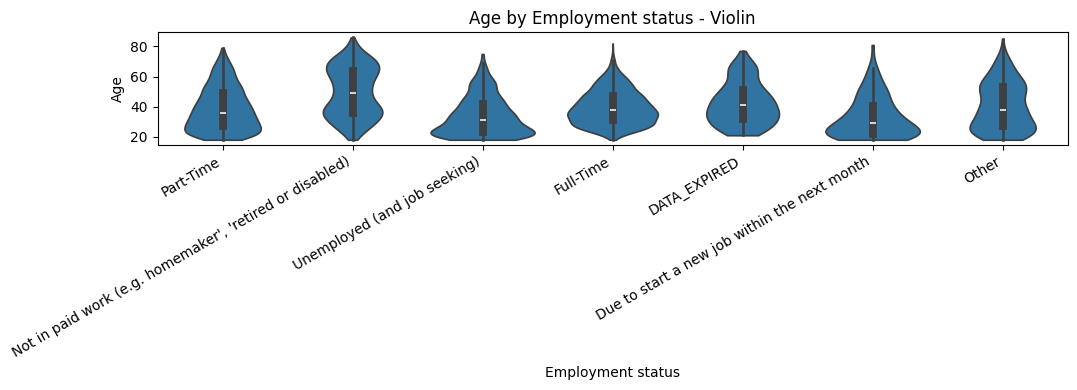

In [18]:
joint = prolific.copy()
joint["Age_num"] = pd.to_numeric(joint["Age"], errors="coerce")

plot_df = joint.dropna(subset=["Age_num", "Employment status"])
plt.figure(figsize=(11, 4))
sns.violinplot(data=plot_df, x="Employment status", y="Age_num", inner="box", cut=0)
plt.title("Age by Employment status - Violin")
plt.xlabel("Employment status")
plt.ylabel("Age")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Three-way interaction: Age x Political spectrum (us), stratified by Sex

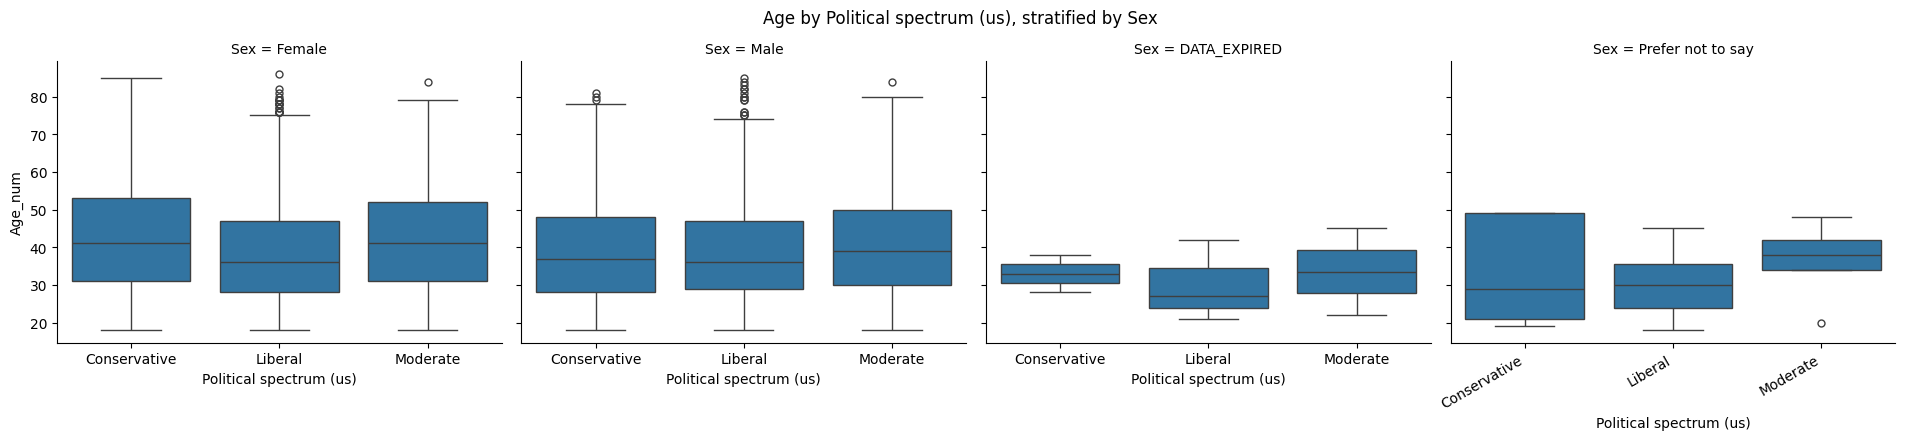

Median age by Sex x Political spectrum (us):


Political spectrum (us),Conservative,Liberal,Moderate
Sex,,,
DATA_EXPIRED,33.0,27.0,33.5
Female,41.0,36.0,41.0
Male,37.0,36.0,39.0
Prefer not to say,29.0,30.0,38.0


In [19]:
three_way = prolific.copy()
three_way["Age_num"] = pd.to_numeric(three_way["Age"], errors="coerce")

plot_df = three_way.dropna(subset=["Age_num", "Political spectrum (us)", "Sex"]).copy()

# Faceted boxplots: Age distribution across political groups within each sex
sns.catplot(
    data=plot_df,
    x="Political spectrum (us)",
    y="Age_num",
    col="Sex",
    kind="box",
    height=4,
    aspect=1.2,
    sharey=True,
)
plt.xticks(rotation=30, ha="right")
plt.subplots_adjust(top=0.85)
plt.suptitle("Age by Political spectrum (us), stratified by Sex")
plt.show()

print("Median age by Sex x Political spectrum (us):")
display(
    plot_df
    .groupby(["Sex", "Political spectrum (us)"])["Age_num"]
    .median()
    .unstack()
    .round(2)
)

## Three-way interaction: Political spectrum (us) x Ethnicity simplified, stratified by Student status

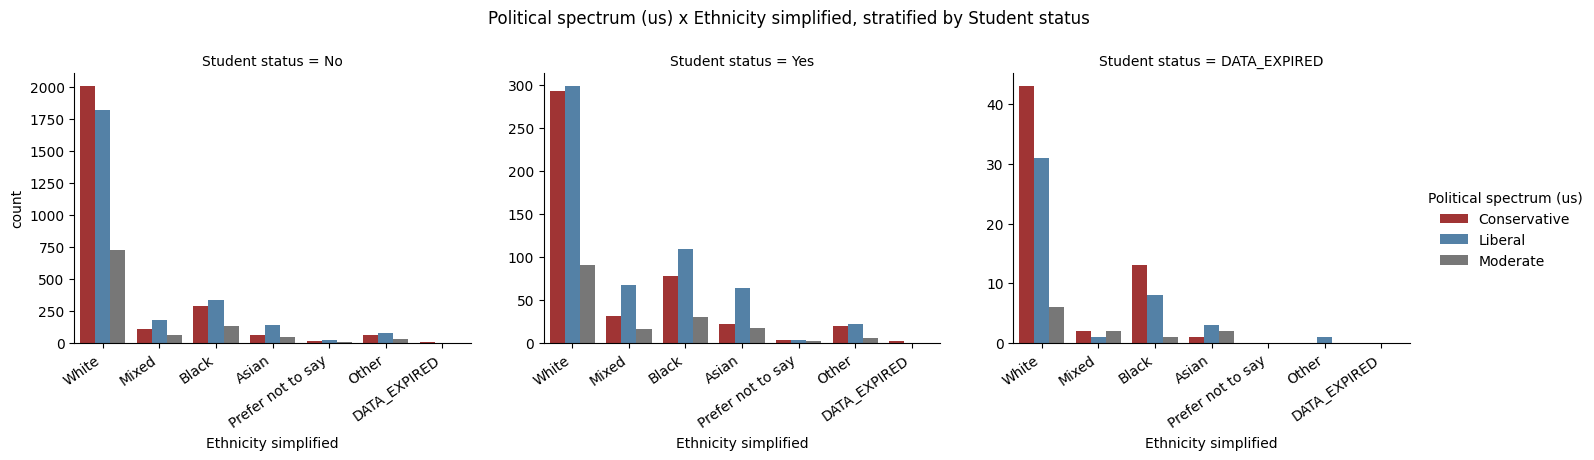

Row-normalized crosstabs within each Student status (Ethnicity -> Political spectrum %):

Student status: DATA_EXPIRED


Political spectrum (us),Conservative,Liberal,Moderate
Ethnicity simplified,,,
Asian,16.7,50.0,33.3
Black,59.1,36.4,4.5
Mixed,40.0,20.0,40.0
Other,0.0,100.0,0.0
White,53.8,38.8,7.5



Student status: No


Political spectrum (us),Conservative,Liberal,Moderate
Ethnicity simplified,,,
Asian,25.1,54.9,20.0
Black,38.2,44.1,17.7
DATA_EXPIRED,88.9,11.1,0.0
Mixed,31.0,51.4,17.5
Other,36.1,45.6,18.3
Prefer not to say,31.9,53.2,14.9
White,44.1,39.9,16.0



Student status: Yes


Political spectrum (us),Conservative,Liberal,Moderate
Ethnicity simplified,,,
Asian,21.2,61.5,17.3
Black,35.9,50.2,13.8
DATA_EXPIRED,100.0,0.0,0.0
Mixed,27.8,58.3,13.9
Other,41.7,45.8,12.5
Prefer not to say,40.0,40.0,20.0
White,42.9,43.8,13.4


In [20]:
three_way = prolific.copy()

plot_df = three_way.dropna(subset=["Political spectrum (us)", "Ethnicity simplified", "Student status"]).copy()

# Faceted normalized composition bars within each ethnicity by student-status panel.
g = sns.catplot(
    data=plot_df,
    x="Ethnicity simplified",
    hue="Political spectrum (us)",
    col="Student status",
    kind="count",
    height=4,
    aspect=1.2,
    sharey=False,
    palette=political_spectrum_palette,
)
for ax in g.axes.flatten():
    for tick in ax.get_xticklabels():
        tick.set_rotation(35)
        tick.set_horizontalalignment("right")

plt.subplots_adjust(top=0.82)
g.figure.suptitle("Political spectrum (us) x Ethnicity simplified, stratified by Student status")
plt.show()

print("Row-normalized crosstabs within each Student status (Ethnicity -> Political spectrum %):")
for status, grp in plot_df.groupby("Student status"):
    print(f"\nStudent status: {status}")
    pct = pd.crosstab(
        grp["Ethnicity simplified"],
        grp["Political spectrum (us)"],
        normalize="index",
    ) * 100
    display(pct.round(1))